# Merton Jump-Diffusion

A price model with **crashes**.

`GeometricBrownianMotion` moves in a continuous wiggle, so it can drift
a long way but never lurches. Real prices lurch -- a bad earnings
report moves them all at once. Merton's model adds exactly that:
occasional sudden jumps at random times, on top of the everyday wiggle.

That means two sources of movement, each with its own settings:

- `scale` -- the everyday wiggle, same as in `GeometricBrownianMotion`
- `jump_rate` -- how often jumps arrive
- `jump_mean` -- which way they go on average (negative = downward)
- `jump_sd` -- how much their size varies

In [1]:
from symbulate import *
import matplotlib.pyplot as plt
from math import exp

## Simulate some paths

A \$100 share, growing 5% a year, with about one jump a year that is
downward on average. Look for the near-vertical drops -- those are the
jumps. The smooth stretches in between are ordinary geometric Brownian
motion.

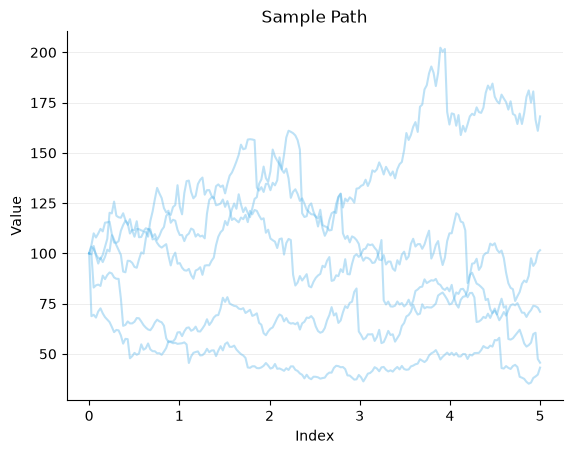

In [2]:
X = MertonJumpDiffusion(
    initial=100,
    growth_rate=0.05,
    scale=0.2,
    jump_rate=1,
    jump_mean=-0.15,
    jump_sd=0.1,
)

X.sim(5).plot(tmin=0, tmax=5)

## Compare with no jumps at all

Same growth rate, same everyday wiggle, jumps removed. These paths are
smooth all the way through -- nothing ever happens suddenly.

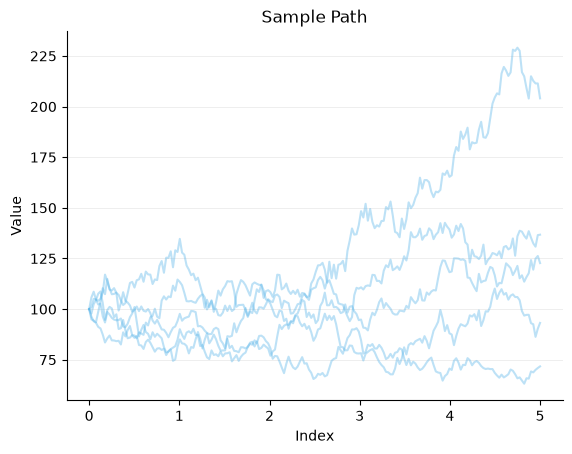

In [3]:
smooth = GeometricBrownianMotion(initial=100, growth_rate=0.05, scale=0.2)

smooth.sim(5).plot(tmin=0, tmax=5)

## Where the jumps came from

A Merton path is built from two pieces, and it keeps both. `jump_path`
is a `CompoundPoissonProcess` -- the running total of the jumps -- and
`brownian_path` is the wiggle. Marking the jump times on a single path
shows they line up with the drops.

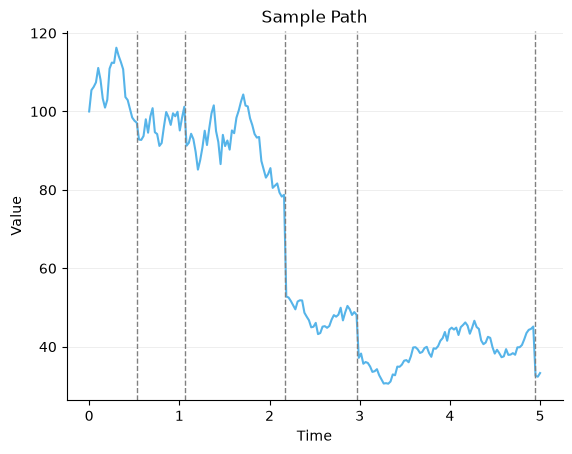

In [4]:
path = X.draw()
gaps = path.jump_path.interarrival_times

jump_times, when = [], 0
for i in range(20):
    when += gaps[i]
    if when > 5:
        break
    jump_times.append(when)

path.plot(tmin=0, tmax=5)
for when in jump_times:
    plt.axvline(when, color="gray", linestyle="--", linewidth=1)

## The jumps do not change the average

This is the part worth knowing. A jump *multiplies* the price, and a
multiplier averages more than 1 even when its log averages 0 -- so
jumps would push the average up all by themselves. The model corrects
for that, so `growth_rate` keeps meaning the growth of the average:
`initial * exp(growth_rate * t)`, exactly as for
`GeometricBrownianMotion`.

Turn the jumps up as far as you like -- the average stays put and only
the spread grows. Watch the `sd` column below explode while the
`average` column does not.

One caveat on reading that last row: once the spread is this large the
simulated average is itself unreliable, so expect it to wobble by a few
dollars run to run. It is the theory that fixes the average at 110.52;
3000 paths are simply not enough to pin it down when the sd is near 200.

In [5]:
settings = dict(initial=100, growth_rate=0.05, scale=0.2)

print(f"expected average at year 2:  {100 * exp(0.05 * 2):.2f}\n")

for rate, mean, sd in [(1, 0.0, 0.1), (1, -0.15, 0.1), (5, -0.3, 0.4)]:
    values = MertonJumpDiffusion(
        jump_rate=rate, jump_mean=mean, jump_sd=sd, **settings
    )[2].sim(3000)
    print(
        f"rate={rate}, mean={mean:>5}, sd={sd}:  "
        f"average {values.mean():7.2f}   sd {values.sd():7.2f}"
    )

expected average at year 2:  110.52

rate=1, mean=  0.0, sd=0.1:  average  109.46   sd   36.05
rate=1, mean=-0.15, sd=0.1:  average  110.56   sd   41.10
rate=5, mean= -0.3, sd=0.4:  average  116.11   sd  224.10


## Why the model exists: a fatter crash tail

Plain geometric Brownian motion is criticised for making a crash too
unlikely. Downward jumps fix that. With no growth over two years, count
how many paths end below \$60:

In [6]:
merton = MertonJumpDiffusion(
    initial=100, growth_rate=0, scale=0.2,
    jump_rate=1, jump_mean=-0.3, jump_sd=0.2,
)[2].sim(3000)
plain = GeometricBrownianMotion(
    initial=100, growth_rate=0, scale=0.2,
)[2].sim(3000)

print(f"Merton ended below $60:  {merton.count_lt(60)} of 3000")
print(f"plain  ended below $60:  {plain.count_lt(60)} of 3000")

Merton ended below $60:  767 of 3000
plain  ended below $60:  145 of 3000


Side by side, the Merton prices reach further down the left-hand side:

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


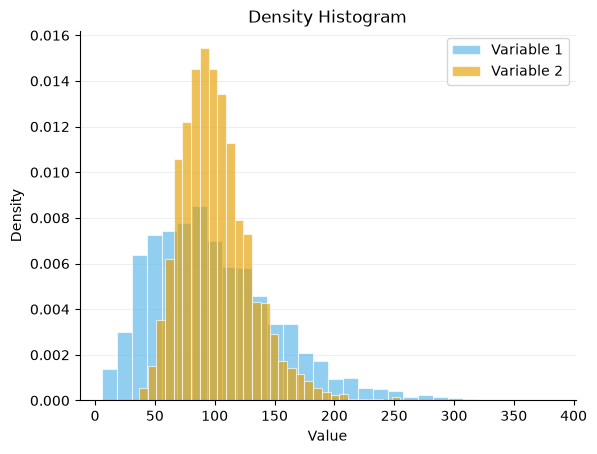

In [7]:
merton.plot()
plain.plot()

## Two things to know

**1. It is built exactly, by composition.** A Merton path is a Brownian
motion and a `CompoundPoissonProcess` of jumps added together in the
exponent, then exponentiated. Both pieces are exact, so there is no step
size to tune and no accumulated error -- unlike `DiffusionProcess`. The
details are in `symbulate/diffusion_process.py`.

**2. `jump_mean` and `jump_sd` describe the jump's *log* size.** A jump
multiplies the price by `exp(J)` where `J` is `Normal(jump_mean,
jump_sd)`. So `jump_mean=-0.15` means a typical jump multiplies by about
`exp(-0.15)` = 0.86, a 14% drop. Working in logs is what keeps the price
positive no matter how large a jump is.